# PPT 발표 자료 출력(EDA, 학습 결과) 및 모델 학습 과정을 정리한 코드입니다.

# 0. 라이브러리 임포트 및 기본 설정
본 분석은 시군구별 데이터를 바탕으로 지방 소멸 위기 여부를 이진 분류하고, 이에 영향을 미치는 주요 요인을 머신러닝 앙상블 모델을 통해 도출하는 것을 목적으로 합니다.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os
import platform
import warnings
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

warnings.filterwarnings('ignore') # 경고 메시지 숨기기

# --- 한글 폰트 및 시각화 기본 설정 ---
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')

plt.rc('axes', unicode_minus=False)
sns.set_style("whitegrid")
os.makedirs('plots', exist_ok=True) # 시각화 저장용 폴더 생성

# --- 모델 성능 지표 시각화 및 자동 저장 함수 ---
def save_performance_plots(model, X_test, y_test, model_name):
    # 1. Confusion Matrix
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.savefig(f'plots/{model_name}_cm.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 2. ROC Curve
    y_score = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}', color='red', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'{model_name} ROC Curve')
    plt.legend(loc='lower right')
    plt.savefig(f'plots/{model_name}_roc.png', dpi=300, bbox_inches='tight')
    plt.show()
# 1. 한글 폰트 설정 (윈도우 환경)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 2. 마이너스(-) 기호 깨짐 방지
# 폰트를 변경하면 축의 마이너스 기호가 깨지는 현상이 발생하므로 이를 방지합니다.
plt.rcParams['axes.unicode_minus'] = False


# 1. 데이터 불러오기 및 분석용 데이터프레임 생성

In [4]:
import os
os.chdir('C://python//SKN25-2nd-2Team/')

In [5]:
file_path = 'data/최종_전처리완료.csv' # 실제 환경에 맞게 경로 수정 필요
try:
    # thousands=',' 옵션으로 천 단위 콤마 제거
    df_full = pd.read_csv(file_path, encoding='cp949', thousands=',')
    print(f"'{file_path}' 성공적으로 로드 완료.")
except Exception as e:
    print(f"파일 로드 오류: {e}")
    df_full = pd.DataFrame()

if not df_full.empty:
    # 컬럼 인덱스를 통한 분석 변수 추출
    year_col_name = df_full.columns[5]       # 연도
    sigungu_col_name = df_full.columns[4]    # 시군구
    target_col_name = df_full.columns[11]    # 개선 인구 소멸 지수
    feature_cols = df_full.columns[12:81].tolist() # M열~CC열 Feature
    
    selected_columns = [year_col_name, sigungu_col_name, target_col_name] + feature_cols
    df = df_full[selected_columns].copy()
    
    # 데이터 형변환 (에러 발생 시 NaN)
    df[target_col_name] = pd.to_numeric(df[target_col_name], errors='coerce')
    df[year_col_name] = df[year_col_name].astype(int)
    
    print(f"분석 대상 Feature 개수: {len(feature_cols)}개")

'data/최종_전처리완료.csv' 성공적으로 로드 완료.
분석 대상 Feature 개수: 69개


# 2. 탐색적 데이터 분석 (EDA) 및 시각화 (PNG 저장)

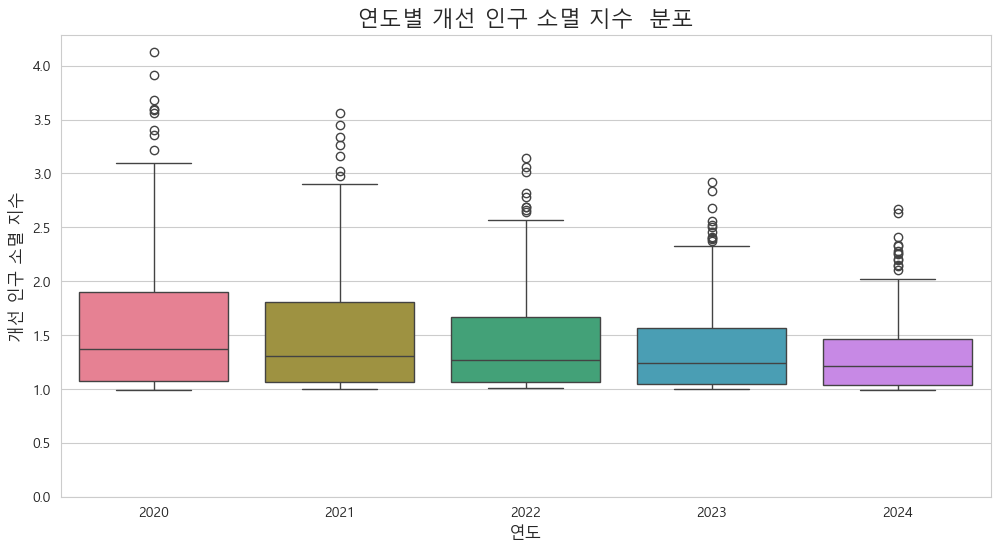

In [13]:
# --- 1. Target 변수 연도별 분포 (Boxplot) ---
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x=year_col_name, y=target_col_name, palette='husl')

plt.title(f'연도별 {target_col_name} 분포', fontsize=16)
plt.xlabel('연도', fontsize=12)                   # x축 라벨을 연도로 변경
plt.ylabel('개선 인구 소멸 지수', fontsize=12)    # y축 라벨을 지수 값으로 변경
plt.ylim(bottom=0)
plt.savefig('plots/1_target_boxplot_distribution.png', dpi=300, bbox_inches='tight') # 파일명 변경
plt.show()

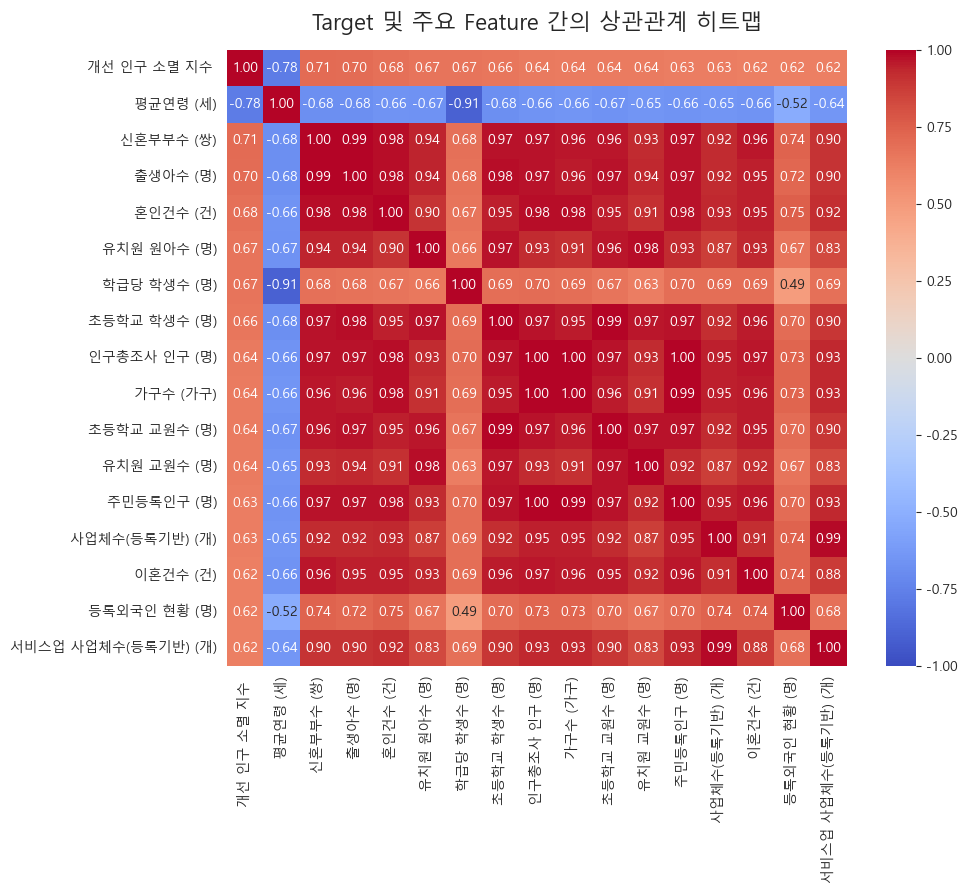

In [7]:
# --- 2. 주요 변수 상관관계 히트맵 ---
corr_matrix = df.select_dtypes(include=[np.number]).corr(method='pearson', min_periods=1)
top_corr_features = corr_matrix[target_col_name].abs().sort_values(ascending=False).index[1:17]

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_corr_features.insert(0, target_col_name)].corr(), 
            annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Target 및 주요 Feature 간의 상관관계 히트맵', fontsize=16, pad=15)
plt.savefig('plots/2_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

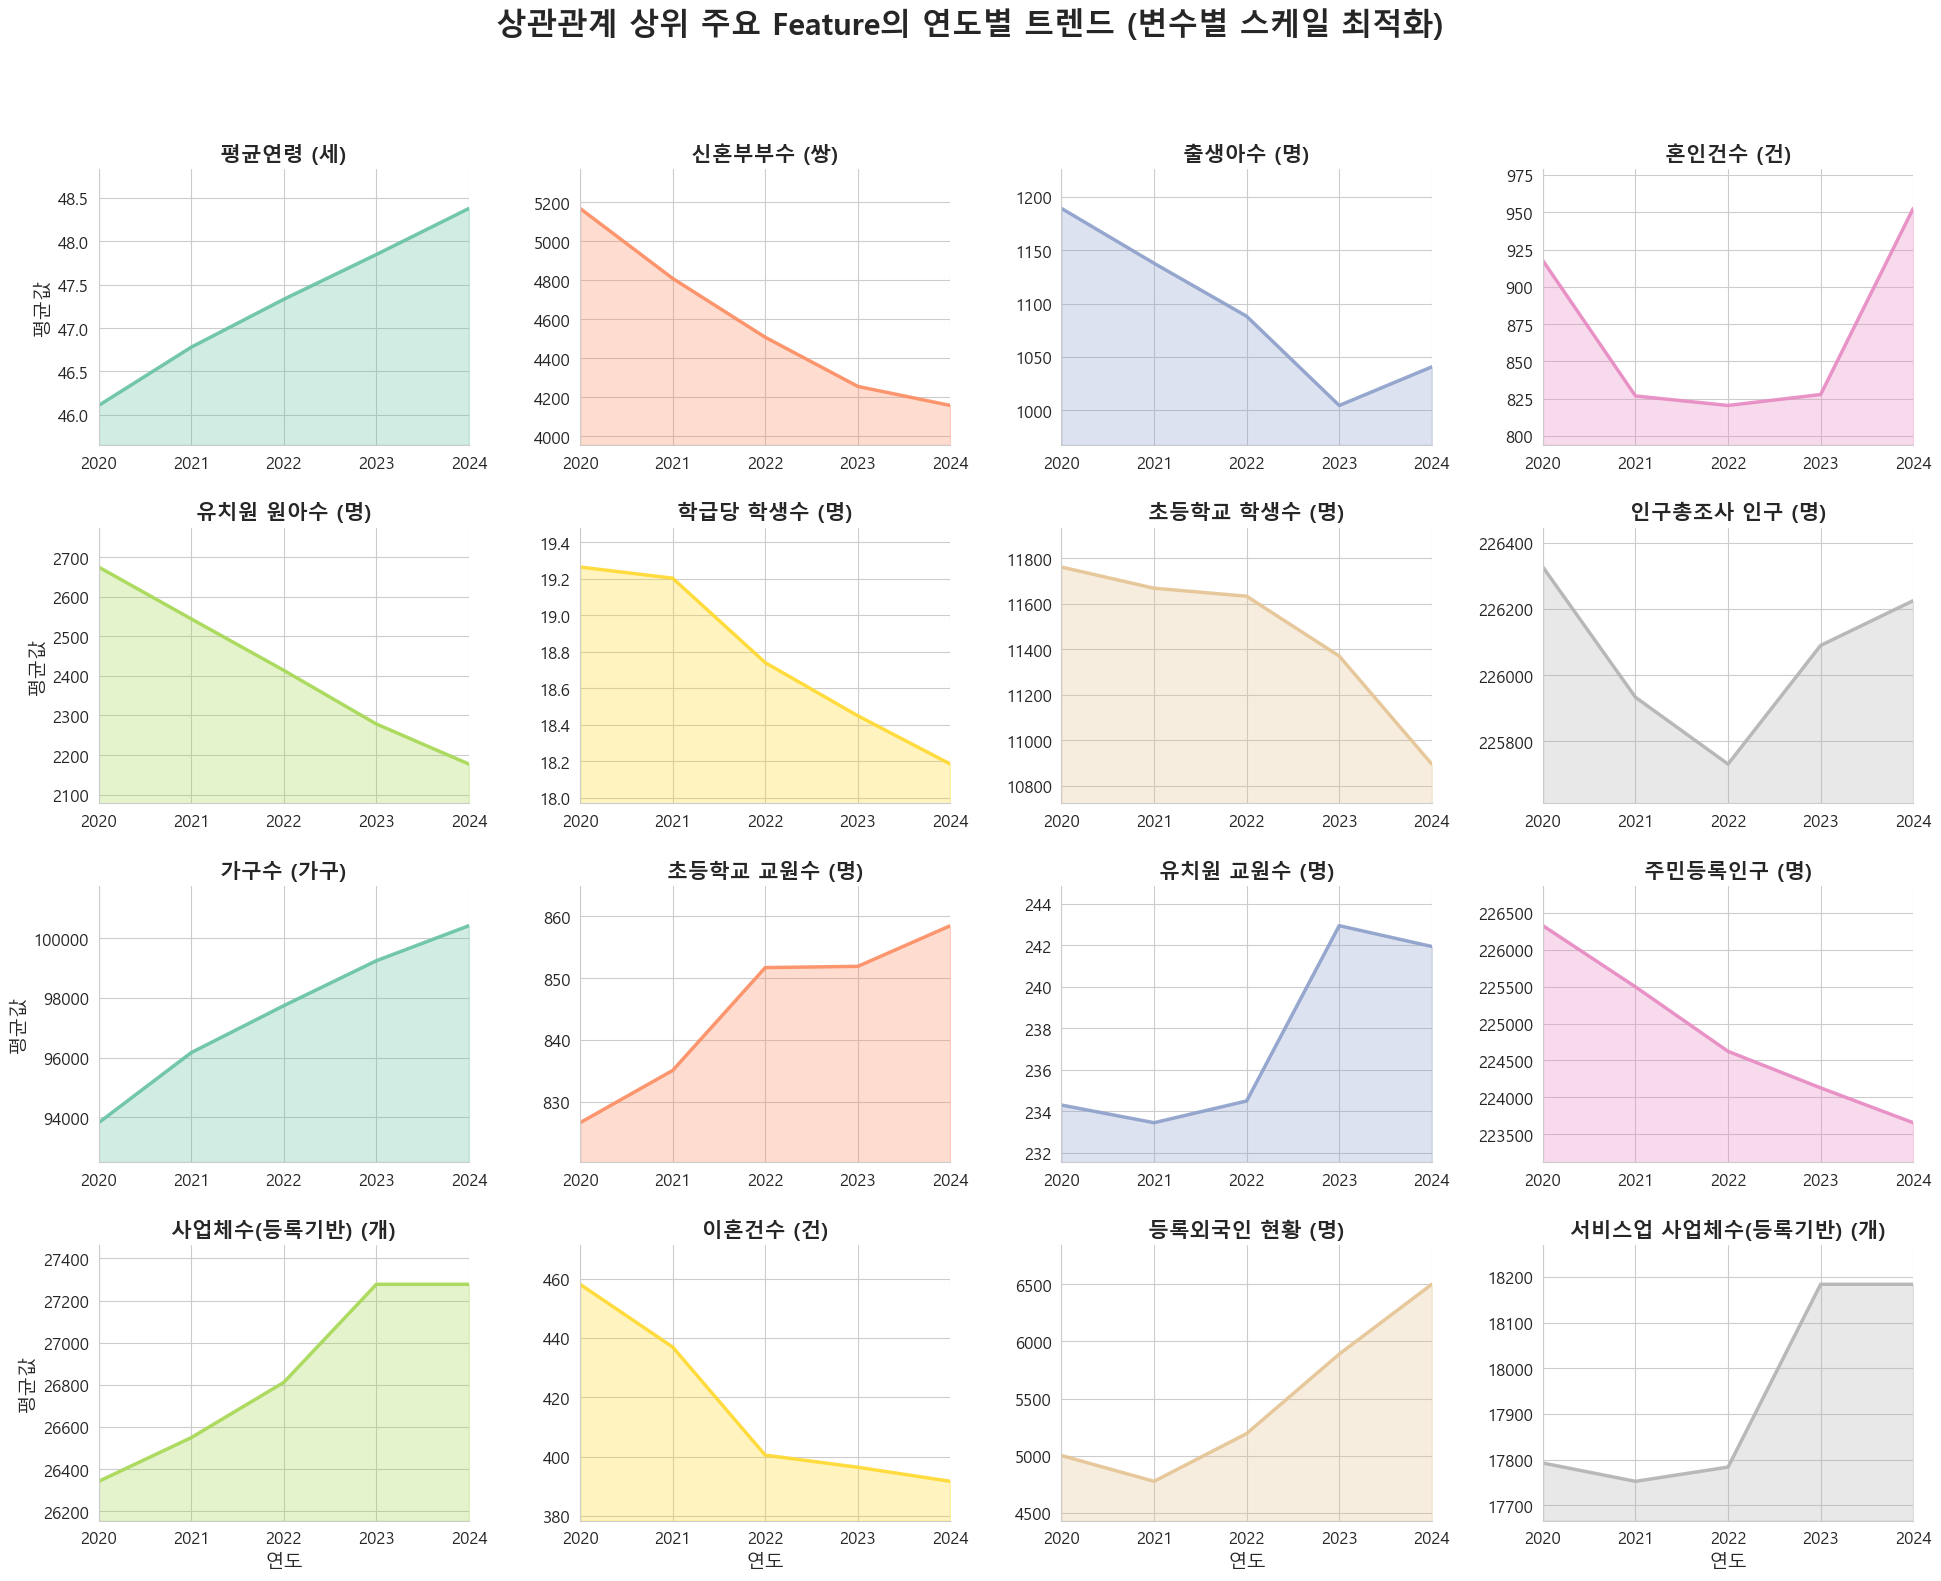

In [12]:
# --- 3. 주요 Feature 시계열 트렌드 (Area Chart) ---
df_ts = df.copy()
df_grouped_mean = df_ts.groupby(year_col_name)[top_corr_features].mean().reset_index()
df_plot_melted = df_grouped_mean.melt(id_vars=year_col_name, var_name='Feature', value_name='Average Value')

# 1. 연도의 최소값, 최대값 추출 (xlim 설정용)
year_min = df_ts[year_col_name].min()
year_max = df_ts[year_col_name].max()
unique_years = df_ts[year_col_name].unique()

def custom_area_plot(x, y, color, **kwargs):
    ax = plt.gca()
    ax.plot(x, y, linewidth=2.5, color=color, alpha=0.9)
    y_min, y_max = y.min(), y.max()
    y_margin = (y_max - y_min) * 0.2 if y_max != y_min else y_min * 0.2
    lower_bound = y_min - y_margin
    ax.set_ylim(lower_bound, y_max + y_margin)
    ax.fill_between(x, lower_bound, y, color=color, alpha=0.3)

# 2. sharex=False 추가: 모든 개별 subplot에 x축 눈금이 표시되도록 설정
g = sns.FacetGrid(df_plot_melted, col='Feature', hue='Feature', 
                  col_wrap=4, height=4, aspect=1.2, palette='Set2', 
                  sharey=False, sharex=False)
g.map(custom_area_plot, year_col_name, 'Average Value')

# 3. 모든 subplot에 동일한 xticks와 xlim 명시적 적용
g.set(xticks=unique_years, xlim=(year_min, year_max))

g.set_titles(col_template="{col_name}", size=15, fontweight='bold')
g.set_axis_labels('연도', '평균값', fontsize=14)

for ax in g.axes.flatten():
    ax.tick_params(labelsize=12)
    # 팁: 만약 연도 글씨가 길어서 겹친다면 아래 코드의 주석을 풀고 45도 회전시켜보세요.
    # ax.tick_params(axis='x', rotation=45)

plt.subplots_adjust(top=0.88, hspace=0.3, wspace=0.3)
g.fig.suptitle('상관관계 상위 주요 Feature의 연도별 트렌드 (변수별 스케일 최적화)', fontsize=22, fontweight='bold')
plt.savefig('plots/3_timeseries_trend_area_chart.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# --- 4. 연도별 기초 통계량 및 Target 변수 분포 확인 ---
if not df.empty:
    print("--- 연도별 기초 통계량 ---")
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.float_format', '{:.2f}'.format):
        display(df.groupby(year_col_name).describe().T)

--- 연도별 기초 통계량 ---


year                              2020         2021         2022         2023  \
개선 인구 소멸 지수         count       229.00       229.00       229.00       229.00   
                    mean          1.56         1.49         1.43         1.37   
                    std           0.63         0.54         0.46         0.40   
                    min           0.99         1.00         1.01         1.00   
                    25%           1.07         1.06         1.06         1.05   
                    50%           1.37         1.31         1.27         1.24   
                    75%           1.90         1.81         1.67         1.57   
                    max           4.13         3.56         3.14         2.92   
노인여가복지시설수           count       229.00       229.00       229.00       229.00   
                    mean        298.75       301.33       302.50       304.74   
                    std         179.56       181.08       181.90       182.84   
                    min          27.00        26.00        26.00        26.00   
                    25%         157.00       155.00       156.00       165.00   
                    50%         276.00       277.00       279.00       281.00   
                    75%         395.00       396.00       399.00       401.00   
                    max        1062.00      1060.00      1070.00      1076.00   
노인인구 1000명 당 여가복지시설 count       229.00       229.00       229.00       229.00   
                    mean         12.71        12.31        12.02        11.71   
                    std           9.50         9.35         9.28         9.15   
                    min           1.79         1.71         1.65         1.60   
                    25%           4.00         3.78         3.63         3.53   
                    50%          10.60        10.22         9.77         9.31   
                    75%          19.22        18.84        18.60        18.14   
                    max          40.06        39.34        39.24        38.46   
문화시설 수              count       229.00       229.00       229.00       229.00   
                    mean         13.48        13.73        14.18        14.38   
                    std           9.95        10.06        10.15        10.10   
                    min           3.00         3.00         2.00         4.00   
                    25%           7.00         8.00         8.00         8.00   
                    50%          11.00        11.00        12.00        12.00   
                    75%          15.00        16.00        16.00        16.00   
                    max          71.00        69.00        70.00        71.00   
인구 십만명당 문화시설 수      count       229.00       229.00       229.00       229.00   
                    mean         11.47        11.77        12.34        12.52   
                    std          10.26        10.60        11.13        11.22   
                    min           1.50         1.50         2.00         2.10   
                    25%           3.90         4.10         4.20         4.40   
                    50%           7.80         7.90         8.80         8.90   
                    75%          15.40        16.00        16.60        16.60   
                    max          72.40        73.90        76.90        77.70   
상급종합병원              count       229.00       229.00       229.00       229.00   
                    mean          0.18         0.20         0.20         0.20   
                    std           0.47         0.46         0.46         0.46   
                    min           0.00         0.00         0.00         0.00   
                    25%           0.00         0.00         0.00         0.00   
                    50%           0.00         0.00         0.00         0.00   
                    75%           0.00         0.00         0.00         0.00   
                    max           3.00         2.00         2.00         2.00   
종합병원                count      

# 3. 소멸 위기 여부 생성 및 BIC 기반 Stepwise 변수 선택
과적합 방지를 위해 임시 스케일링 상태에서 **BIC(Bayesian Information Criterion) 값이 낮아지는 방향**으로만 타겟에 유의미한 변수를 추출하는 Stepwise 기법을 적용합니다.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

if not df.empty:
    years = sorted(df[year_col_name].unique())
    threshold = 1.04
    top_features_per_year = {}
    
    print(f"--- 연도별 RF 변수 중요도 기반 핵심 변수 추출 (Top 40) ---\n")
    
    for year in years:
        # 1. 연도별 데이터 필터링 및 소멸위기 타겟 생성
        df_year = df[df[year_col_name] == year].copy()
        y_year = (df_year[target_col_name] < threshold).astype(int)
        
        # 2. Feature(X) 세팅 (문자열 및 식별컬럼 제거)
        X_year = df_year.drop(columns=[year_col_name, sigungu_col_name, target_col_name], errors='ignore')
        X_year = X_year.replace(',', '', regex=True).apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all')
        X_year = X_year.fillna(X_year.mean()) # 결측치 평균 대체
        
        # 3. Random Forest 모델 학습 (해당 연도 데이터 기준)
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X_year, y_year)
        
        # 4. 변수 중요도 상위 40개 추출
        importances = pd.Series(rf.feature_importances_, index=X_year.columns)
        top_40 = importances.sort_values(ascending=False).head(40).index.tolist()
        
        # 집합(Set) 형태로 저장하여 나중에 교집합을 구하기 쉽게 세팅
        top_features_per_year[year] = set(top_40)
        print(f"[{year}년] 변수 중요도 Top 40 추출 완료")

    # 5. 모든 연도(예: 2020~2024)에 공통으로 존재하는 변수(교집합) 찾기
    common_features = set.intersection(*top_features_per_year.values())
    final_features = list(common_features)
    
    print(f"\n✅ 모든 연도 상위 40위 내 공통 핵심 변수 ({len(final_features)}개): \n{final_features}")

    # -------------------------------------------------------------
    # 6. 추려진 최종 공통 변수들로만 2024년 데이터 기준 Scaling 진행
    # -------------------------------------------------------------
    if len(final_features) > 0:
        # 2024년 데이터 다시 준비 (최종 모델 학습 및 예측용)
        df_2024 = df[df[year_col_name] == 2024].copy()
        y = (df_2024[target_col_name] < threshold).astype(int)
        
        X_2024 = df_2024.drop(columns=[year_col_name, sigungu_col_name, target_col_name], errors='ignore')
        X_2024 = X_2024.replace(',', '', regex=True).apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all')
        X_2024 = X_2024.fillna(X_2024.mean())
        
        # 최종 교집합 변수만 선택
        X_final_raw = X_2024[final_features]
        
        # 선택된 변수 정식 스케일링
        final_scaler = StandardScaler()
        X_final_scaled = pd.DataFrame(final_scaler.fit_transform(X_final_raw), 
                                      columns=X_final_raw.columns, index=X_final_raw.index)
        
        print("\n--- 최종 추출된 변수 스케일링 완료 (X_final_scaled) ---")
        display(X_final_scaled.head())
    else:
        print("\n❌ 모든 연도에 공통으로 속하는 Top 40 변수가 없습니다. Top N 개수를 늘려보세요.")

--- 연도별 RF 변수 중요도 기반 핵심 변수 추출 (Top 40) ---

[2020년] 변수 중요도 Top 40 추출 완료
[2021년] 변수 중요도 Top 40 추출 완료
[2022년] 변수 중요도 Top 40 추출 완료
[2023년] 변수 중요도 Top 40 추출 완료
[2024년] 변수 중요도 Top 40 추출 완료

✅ 모든 연도 상위 40위 내 공통 핵심 변수 (23개): 
['고용률', '노인여가복지시설수', '초등학교 학생수 (명)', '가구수 (가구)', '도소매업 사업체수(등록기반) (개)', '도소매업 종사자수(등록기반) (명)', '서비스업 사업체수(등록기반) (개)', '평균연령 (세)', '유치원 교원수 (명)', '혼인건수 (건)', '학급당 학생수 (명)', '출생아수 (명)', '신혼부부수 (쌍)', '제조업 사업체수(등록기반) (개)', '인구총조사 인구 (명)', '주민등록인구 (명)', '하수도보급률 (%)', '노인인구 1000명 당 여가복지시설', '운수업 종사자수(등록기반) (명)', '초등학교 교원수 (명)', '조혼인율 (천명당)', '이혼건수 (건)', '유치원 원아수 (명)']

--- 최종 추출된 변수 스케일링 완료 (X_final_scaled) ---


,고용률,노인여가복지시설수,초등학교 학생수 (명),가구수 (가구),도소매업 사업체수(등록기반) (개),도소매업 종사자수(등록기반) (명),서비스업 사업체수(등록기반) (개),평균연령 (세),유치원 교원수 (명),혼인건수 (건),...,제조업 사업체수(등록기반) (개),인구총조사 인구 (명),주민등록인구 (명),하수도보급률 (%),노인인구 1000명 당 여가복지시설,운수업 종사자수(등록기반) (명),초등학교 교원수 (명),조혼인율 (천명당),이혼건수 (건),유치원 원아수 (명)
4,-0.521366,0.072919,-0.194784,0.005115,-0.069444,-0.084575,0.147214,-0.097463,-0.255425,-0.192664,...,-0.270310,-0.061492,-0.071419,0.342758,-0.577829,-0.184927,-0.066220,-0.192045,-0.009400,-0.286525
9,0.843238,-1.047963,-0.807010,-0.900808,-0.881143,-0.766569,-0.848304,0.573937,-0.833419,-0.798313,...,-0.663368,-0.879632,-0.881949,0.031743,0.201473,-0.856289,-0.821392,0.091077,-0.855423,-0.797059
14,-0.153203,-0.916738,-0.529109,-0.624001,-0.602035,-0.553756,-0.591968,0.004265,-0.607408,-0.569428,...,-0.554993,-0.622996,-0.609835,0.740568,-0.522028,-0.518954,-0.604265,0.185451,-0.500973,-0.562936
19,-0.193221,-0.326225,-0.709668,-0.722702,-0.719823,-0.652418,-0.681116,0.268755,-0.674100,-0.706006,...,-0.613130,-0.723702,-0.726168,0.133003,0.261996,-0.760955,-0.703284,-0.475167,-0.684666,-0.620602
24,-0.249246,-1.146382,-0.589431,-0.639060,-0.558502,-0.539723,-0.502153,-0.056772,-0.744497,-0.564719,...,-0.603335,-0.649214,-0.640071,0.805664,-0.678994,-0.637151,-0.638862,0.562947,-0.519083,-0.694414


# 4. 최종 변수 Scaling 및 모델링 (Train/Test 분리)

--- 🌟 다중 스텝 직접 예측 (Direct Multi-step Forecasting: XGBoost & CatBoost) ---

🔥 [Model 1] T+1 (2025년 예측)

[ T+1 XGBoost 평가 (Test Year: 2023) ]
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.96       176
         1.0       0.91      0.81      0.86        53

    accuracy                           0.94       229
   macro avg       0.93      0.89      0.91       229
weighted avg       0.94      0.94      0.94       229



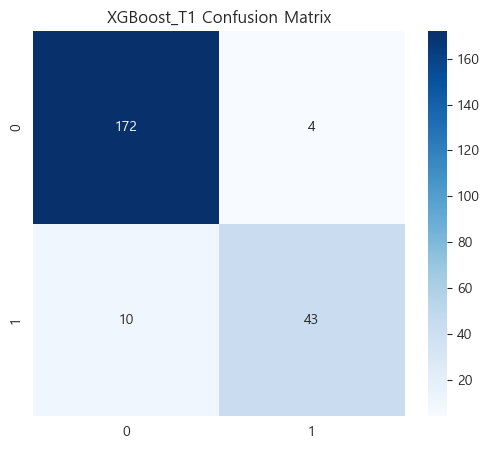

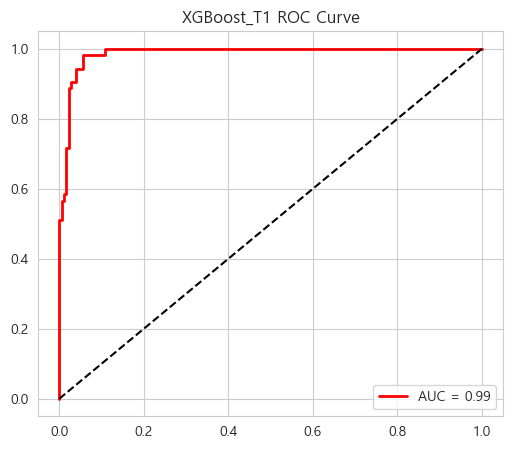


[ T+1 CatBoost 평가 (Test Year: 2023) ]
              precision    recall  f1-score   support

         0.0       0.96      0.97      0.96       176
         1.0       0.88      0.85      0.87        53

    accuracy                           0.94       229
   macro avg       0.92      0.91      0.91       229
weighted avg       0.94      0.94      0.94       229



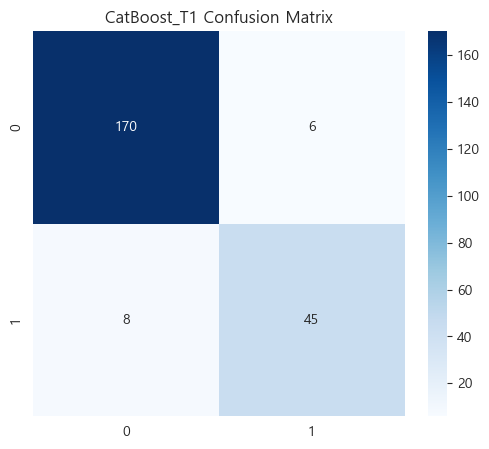

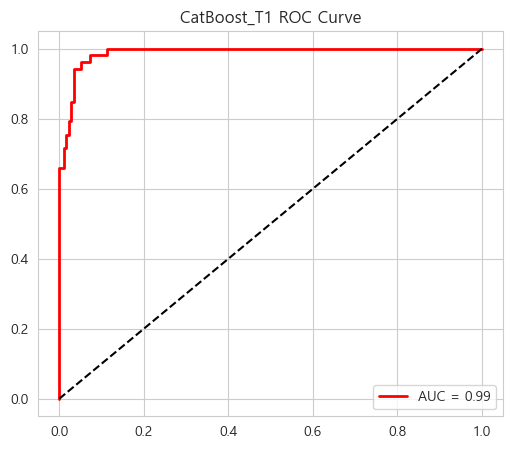


🔥 [Model 2] T+2 (2026년 예측)

[ T+2 XGBoost 평가 (Test Year: 2022) ]
              precision    recall  f1-score   support

         0.0       0.96      0.97      0.96       176
         1.0       0.90      0.85      0.87        53

    accuracy                           0.94       229
   macro avg       0.93      0.91      0.92       229
weighted avg       0.94      0.94      0.94       229



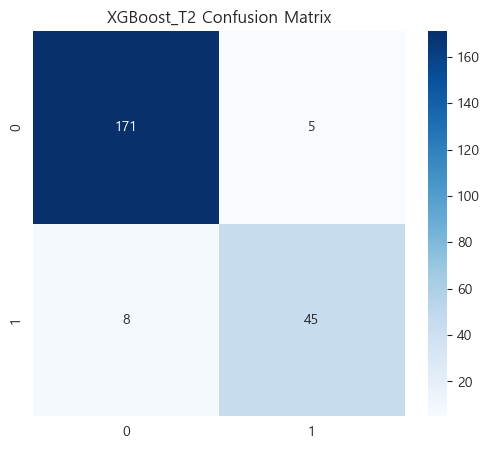

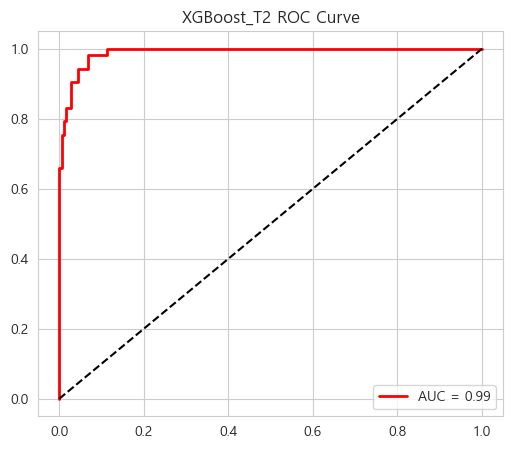


[ T+2 CatBoost 평가 (Test Year: 2022) ]
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97       176
         1.0       0.92      0.89      0.90        53

    accuracy                           0.96       229
   macro avg       0.94      0.93      0.94       229
weighted avg       0.96      0.96      0.96       229



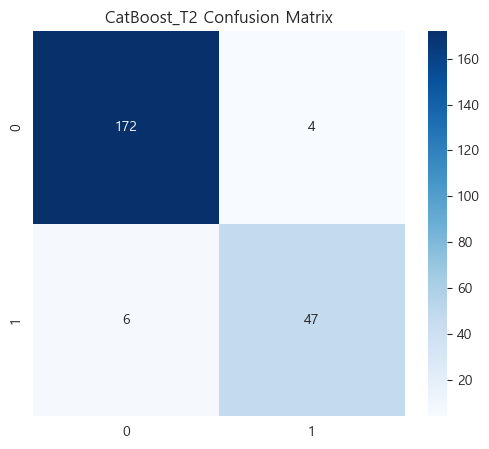

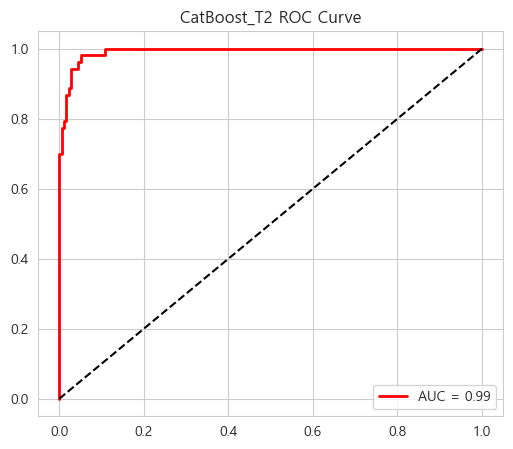


🔥 [Model 3] T+3 (2027년 예측)

[ T+3 XGBoost 평가 (Test Year: 2021) ]
              precision    recall  f1-score   support

         0.0       0.95      0.94      0.94       177
         1.0       0.80      0.83      0.81        52

    accuracy                           0.91       229
   macro avg       0.87      0.88      0.88       229
weighted avg       0.91      0.91      0.91       229



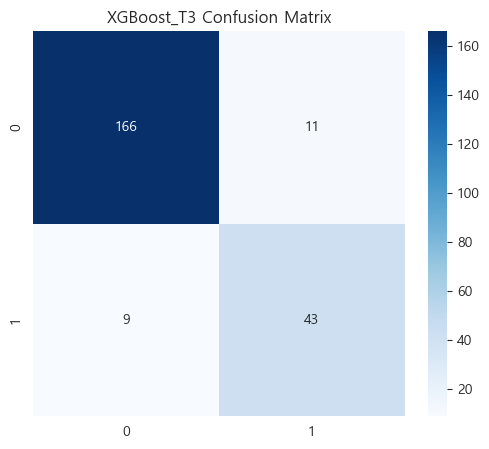

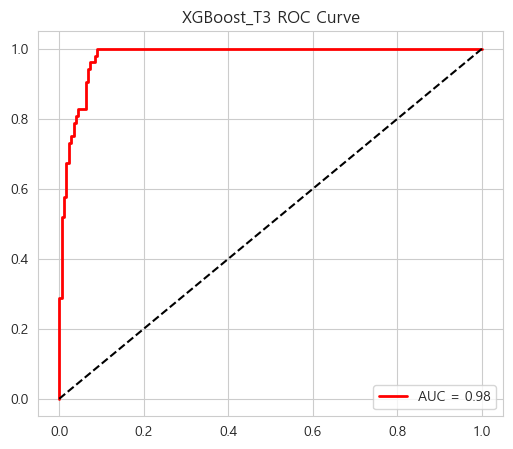


[ T+3 CatBoost 평가 (Test Year: 2021) ]
              precision    recall  f1-score   support

         0.0       0.96      0.97      0.96       177
         1.0       0.88      0.87      0.87        52

    accuracy                           0.94       229
   macro avg       0.92      0.92      0.92       229
weighted avg       0.94      0.94      0.94       229



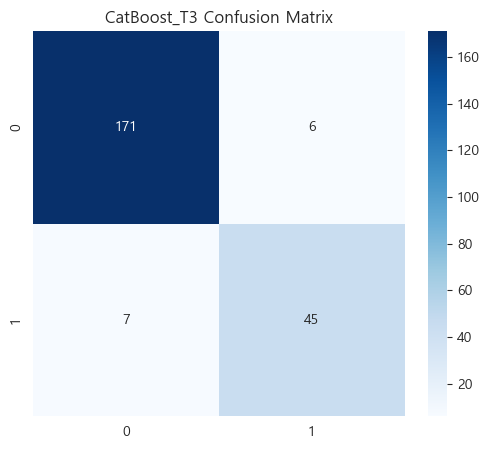

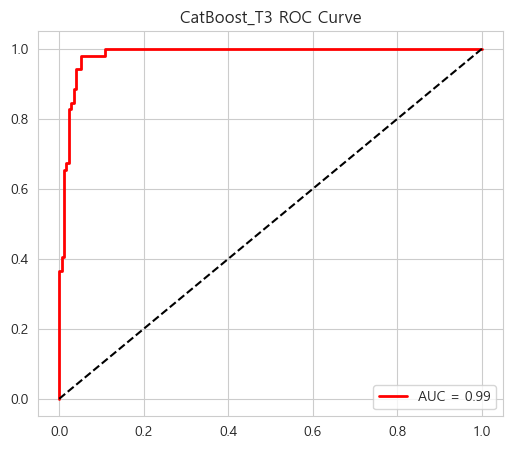


✅ 다중 스텝 예측 완료! 2025~2027년 시군구별 소멸위기 예측 확률 (XGBoost vs CatBoost):


,sigun_nm,prob_2025_XGB,prob_2025_CAT,prob_2026_XGB,prob_2026_CAT,prob_2027_XGB,prob_2027_CAT
4,가평군,0.005450,0.017924,0.087541,0.132629,0.364301,0.510084
9,강남구,0.000204,0.000114,0.000404,0.000180,0.000524,0.000204
14,강동구,0.000204,0.000085,0.000404,0.000132,0.000524,0.000209
19,강릉시,0.000239,0.000285,0.000404,0.000290,0.000796,0.000350
24,강북구,0.000252,0.000181,0.000404,0.000233,0.001078,0.000295
33,강서구,0.000256,0.000326,0.000475,0.000317,0.000603,0.000583
34,강서구,0.000227,0.000104,0.000404,0.000181,0.000524,0.000237
39,강진군,0.995469,0.984356,0.995044,0.987355,0.975416,0.979641
44,강화군,0.717168,0.692260,0.138365,0.549411,0.285602,0.603999
49,거제시,0.000243,0.000232,0.000298,0.000319,0.000646,0.000303


In [15]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import pandas as pd

if not df.empty and len(final_features) > 0:
    print("--- 🌟 다중 스텝 직접 예측 (Direct Multi-step Forecasting: XGBoost & CatBoost) ---")

    # 1. 패널 데이터 정렬 및 시차(Lag) 타겟 생성
    df_model = df.copy().sort_values(by=[sigungu_col_name, year_col_name]).reset_index(drop=True)

    # shift(-1)은 1년 뒤, shift(-2)는 2년 뒤 데이터를 현재 연도 행으로 가져옵니다.
    df_model['target_T1'] = df_model.groupby(sigungu_col_name)[target_col_name].shift(-1)
    df_model['target_T2'] = df_model.groupby(sigungu_col_name)[target_col_name].shift(-2)
    df_model['target_T3'] = df_model.groupby(sigungu_col_name)[target_col_name].shift(-3)

    threshold = 1.04
    df_model['y_T1'] = (df_model['target_T1'] < threshold).astype(float)
    df_model['y_T2'] = (df_model['target_T2'] < threshold).astype(float)
    df_model['y_T3'] = (df_model['target_T3'] < threshold).astype(float)

    # 2. 추출된 공통 핵심 변수만 정식 Scaling 진행
    X_raw = df_model[final_features].replace(',', '', regex=True).apply(pd.to_numeric, errors='coerce')
    X_raw = X_raw.fillna(X_raw.mean())

    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=X_raw.columns, index=X_raw.index)

    # 연도, 시군구, 3개의 타겟과 스케일링된 Feature를 하나의 데이터프레임으로 결합
    df_scaled = pd.concat([df_model[[year_col_name, sigungu_col_name, 'y_T1', 'y_T2', 'y_T3']], X_scaled], axis=1)

    # 공통 모델 하이퍼파라미터 (과적합 방지)
    xgb_params = {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'random_state': 42, 'eval_metric': 'logloss'}
    cat_params = {'iterations': 200, 'depth': 5, 'learning_rate': 0.05, 'random_state': 42, 'verbose': 0}

    # 미래 예측에 사용할 2024년(현재) 데이터 준비
    X_2024 = df_scaled[df_scaled[year_col_name] == 2024][final_features]
    future_predictions = pd.DataFrame({'sigun_nm': df_scaled[df_scaled[year_col_name] == 2024][sigungu_col_name]})

    # ==========================================================
    # 💡 [Model 1] T+1 (1년 뒤: 2025년 위기지역 예측)
    # ==========================================================
    print("\n======================================================")
    print("🔥 [Model 1] T+1 (2025년 예측)")
    print("======================================================")
    
    # [평가용] Train: 2020~2022 -> Test: 2023 
    train_idx = df_scaled[(df_scaled[year_col_name].isin([2020, 2021, 2022])) & (df_scaled['y_T1'].notnull())].index
    test_idx = df_scaled[(df_scaled[year_col_name] == 2023) & (df_scaled['y_T1'].notnull())].index

    y_test = df_scaled.loc[test_idx, 'y_T1']
    X_test = df_scaled.loc[test_idx, final_features]

    # [XGBoost]
    xgb_T1 = XGBClassifier(**xgb_params)
    xgb_T1.fit(df_scaled.loc[train_idx, final_features], df_scaled.loc[train_idx, 'y_T1'])
    print("\n[ T+1 XGBoost 평가 (Test Year: 2023) ]")
    print(classification_report(y_test, xgb_T1.predict(X_test)))
    save_performance_plots(xgb_T1, X_test, y_test, "XGBoost_T1")

    # [CatBoost]
    cat_T1 = CatBoostClassifier(**cat_params)
    cat_T1.fit(df_scaled.loc[train_idx, final_features], df_scaled.loc[train_idx, 'y_T1'])
    print("\n[ T+1 CatBoost 평가 (Test Year: 2023) ]")
    print(classification_report(y_test, cat_T1.predict(X_test)))
    save_performance_plots(cat_T1, X_test, y_test, "CatBoost_T1")

    # [예측용 최종학습] Train: 2020~2023 -> Predict: 2024년 데이터 투입
    final_train_idx = df_scaled[(df_scaled[year_col_name] <= 2023) & (df_scaled['y_T1'].notnull())].index
    
    xgb_T1_final = XGBClassifier(**xgb_params).fit(df_scaled.loc[final_train_idx, final_features], df_scaled.loc[final_train_idx, 'y_T1'])
    cat_T1_final = CatBoostClassifier(**cat_params).fit(df_scaled.loc[final_train_idx, final_features], df_scaled.loc[final_train_idx, 'y_T1'])
    
    future_predictions['prob_2025_XGB'] = xgb_T1_final.predict_proba(X_2024)[:, 1]
    future_predictions['prob_2025_CAT'] = cat_T1_final.predict_proba(X_2024)[:, 1]

    # ==========================================================
    # 💡 [Model 2] T+2 (2년 뒤: 2026년 위기지역 예측)
    # ==========================================================
    print("\n======================================================")
    print("🔥 [Model 2] T+2 (2026년 예측)")
    print("======================================================")
    
    # [평가용] Train: 2020~2021 -> Test: 2022
    train_idx = df_scaled[(df_scaled[year_col_name].isin([2020, 2021])) & (df_scaled['y_T2'].notnull())].index
    test_idx = df_scaled[(df_scaled[year_col_name] == 2022) & (df_scaled['y_T2'].notnull())].index

    y_test = df_scaled.loc[test_idx, 'y_T2']
    X_test = df_scaled.loc[test_idx, final_features]

    # [XGBoost]
    xgb_T2 = XGBClassifier(**xgb_params)
    xgb_T2.fit(df_scaled.loc[train_idx, final_features], df_scaled.loc[train_idx, 'y_T2'])
    print("\n[ T+2 XGBoost 평가 (Test Year: 2022) ]")
    print(classification_report(y_test, xgb_T2.predict(X_test)))
    save_performance_plots(xgb_T2, X_test, y_test, "XGBoost_T2")

    # [CatBoost]
    cat_T2 = CatBoostClassifier(**cat_params)
    cat_T2.fit(df_scaled.loc[train_idx, final_features], df_scaled.loc[train_idx, 'y_T2'])
    print("\n[ T+2 CatBoost 평가 (Test Year: 2022) ]")
    print(classification_report(y_test, cat_T2.predict(X_test)))
    save_performance_plots(cat_T2, X_test, y_test, "CatBoost_T2")

    # [예측용 최종학습] Train: 2020~2022 -> Predict: 2024년 데이터 투입
    final_train_idx = df_scaled[(df_scaled[year_col_name] <= 2022) & (df_scaled['y_T2'].notnull())].index
    
    xgb_T2_final = XGBClassifier(**xgb_params).fit(df_scaled.loc[final_train_idx, final_features], df_scaled.loc[final_train_idx, 'y_T2'])
    cat_T2_final = CatBoostClassifier(**cat_params).fit(df_scaled.loc[final_train_idx, final_features], df_scaled.loc[final_train_idx, 'y_T2'])
    
    future_predictions['prob_2026_XGB'] = xgb_T2_final.predict_proba(X_2024)[:, 1]
    future_predictions['prob_2026_CAT'] = cat_T2_final.predict_proba(X_2024)[:, 1]

    # ==========================================================
    # 💡 [Model 3] T+3 (3년 뒤: 2027년 위기지역 예측)
    # ==========================================================
    print("\n======================================================")
    print("🔥 [Model 3] T+3 (2027년 예측)")
    print("======================================================")
    
    # [평가용] Train: 2020 -> Test: 2021
    train_idx = df_scaled[(df_scaled[year_col_name] == 2020) & (df_scaled['y_T3'].notnull())].index
    test_idx = df_scaled[(df_scaled[year_col_name] == 2021) & (df_scaled['y_T3'].notnull())].index

    y_test = df_scaled.loc[test_idx, 'y_T3']
    X_test = df_scaled.loc[test_idx, final_features]

    # [XGBoost]
    xgb_T3 = XGBClassifier(**xgb_params)
    xgb_T3.fit(df_scaled.loc[train_idx, final_features], df_scaled.loc[train_idx, 'y_T3'])
    print("\n[ T+3 XGBoost 평가 (Test Year: 2021) ]")
    print(classification_report(y_test, xgb_T3.predict(X_test)))
    save_performance_plots(xgb_T3, X_test, y_test, "XGBoost_T3")

    # [CatBoost]
    cat_T3 = CatBoostClassifier(**cat_params)
    cat_T3.fit(df_scaled.loc[train_idx, final_features], df_scaled.loc[train_idx, 'y_T3'])
    print("\n[ T+3 CatBoost 평가 (Test Year: 2021) ]")
    print(classification_report(y_test, cat_T3.predict(X_test)))
    save_performance_plots(cat_T3, X_test, y_test, "CatBoost_T3")

    # [예측용 최종학습] Train: 2020~2021 -> Predict: 2024년 데이터 투입
    final_train_idx = df_scaled[(df_scaled[year_col_name] <= 2021) & (df_scaled['y_T3'].notnull())].index
    
    xgb_T3_final = XGBClassifier(**xgb_params).fit(df_scaled.loc[final_train_idx, final_features], df_scaled.loc[final_train_idx, 'y_T3'])
    cat_T3_final = CatBoostClassifier(**cat_params).fit(df_scaled.loc[final_train_idx, final_features], df_scaled.loc[final_train_idx, 'y_T3'])
    
    future_predictions['prob_2027_XGB'] = xgb_T3_final.predict_proba(X_2024)[:, 1]
    future_predictions['prob_2027_CAT'] = cat_T3_final.predict_proba(X_2024)[:, 1]

    # 최종 예측 결과 출력
    print("\n✅ 다중 스텝 예측 완료! 2025~2027년 시군구별 소멸위기 예측 확률 (XGBoost vs CatBoost):")
    display(future_predictions.head(10))